# Lesson 02: FIX session health (heartbeats, sequence numbers, gaps, disconnects, clocks)
**Level:** beginner → intermediate

The session layer keeps a FIX connection alive and **guarantees that no message is lost or processed twice**.
When it breaks, prices freeze, orders hang and fills go missing. This lesson builds a **session health report**
for the three LP sessions and finds four incidents:

* **S05**: a sequence gap on LP_B, a buggy ResendRequest and a re-sent fill (PossDup)
* **S06**: LP_C goes silent, then TestRequest, Logout and a reconnect with a sequence reset
* **S12**: LP_C's clock runs ahead of ours

**Session-layer messages:**

| 35= | Name | Purpose |
|---|---|---|
| A | Logon | opens the session; `108` HeartBtInt, `141=Y` reset sequence numbers |
| 0 | Heartbeat | "I'm alive": sent after HeartBtInt seconds without any other message |
| 1 | TestRequest | "Are you there?" sent when the other side is silent too long; must be answered by a Heartbeat with the same `112` |
| 2 | ResendRequest | "I missed messages `7`=BeginSeqNo to `16`=EndSeqNo (0 = all)" |
| 4 | SequenceReset | `123=Y` GapFill: "skip these numbers, nothing important in them" |
| 5 | Logout | closes the session (`58` gives the reason) |

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from bridgelab import analysis as A, plotting as P
P.setup()
pd.set_option("display.width", 200, "display.max_columns", 30, "display.max_colwidth", 110)

msgs = A.load_fix_messages()          # the parsing from Lesson 01, applied to all three logs
print(f"{len(msgs):,} messages")
msgs.groupby(["lp", "direction", "msg_name"]).size().unstack(["lp", "direction"]).fillna(0).astype(int)

69,360 messages


lp                              LP_A        LP_B        LP_C     
direction                         IN  OUT     IN  OUT     IN  OUT
msg_name                                                         
ExecutionReport                  433    0    168    0    383    0
Heartbeat                          0  548      0  657      0  555
Logon                              1    1      1    1      2    2
Logout                             0    0      0    0      0    1
MarketDataRequest                  0    1      0    1      0    2
MarketDataSnapshotFullRefresh  21854    0  22149    0  21733    0
NewOrderSingle                     0  390      0  142      0  331
ResendRequest                      0    0      0    1      0    0
SequenceReset                      0    0      2    0      0    0
TestRequest                        0    0      0    0      0    1

## 1. Session events timeline
Logons, logouts, test requests, resend requests and sequence resets are rare. List them all. This is the first
thing to check when someone reports "the LP was down".

In [2]:
admin = msgs[msgs.msg_type.isin(["A", "1", "2", "4", "5"])]
admin[["lp", "log_time", "direction", "msg_name", "seq", "reset_seq", "test_req_id", "begin_seq", "end_seq",
       "new_seq", "gap_fill", "poss_dup", "text"]].fillna("")

,lp,log_time,direction,msg_name,seq,reset_seq,test_req_id,begin_seq,end_seq,new_seq,gap_fill,poss_dup,text
0,LP_A,2025-10-15 11:29:58.500,OUT,Logon,1,Y,,,,,,,
1,LP_B,2025-10-15 11:29:58.500,OUT,Logon,1,Y,,,,,,,
2,LP_C,2025-10-15 11:29:58.500,OUT,Logon,1,Y,,,,,,,
3,LP_A,2025-10-15 11:29:58.507,IN,Logon,1,Y,,,,,,,
5,LP_C,2025-10-15 11:29:58.510,IN,Logon,1,Y,,,,,,,
7,LP_B,2025-10-15 11:29:58.518,IN,Logon,1,Y,,,,,,,
44408,LP_B,2025-10-15 12:45:10.179,OUT,ResendRequest,508,,,14126,0,,,,
44409,LP_B,2025-10-15 12:45:10.192,IN,SequenceReset,14126,,,,,14128,Y,Y,
44411,LP_B,2025-10-15 12:45:10.193,IN,SequenceReset,14129,,,,,14134,Y,Y,
52835,LP_C,2025-10-15 13:00:12.000,OUT,TestRequest,690,,TEST-130012,,,,,,


Two stories appear immediately:
* **LP_C at 13:00**: a TestRequest, then a Logout with *"Heartbeat timeout"*, then a new Logon at 13:02:30 with `141=Y`.
* **LP_B at 12:45:10**: a ResendRequest, answered by SequenceResets (GapFill) and a re-sent message.

## 2. Heartbeats and silence detection
Rule: if nothing arrives from the other side for **HeartBtInt + a margin** (here 10 s + 20%), send a TestRequest.
If there's still no answer, disconnect. Compute the gap between consecutive **incoming** messages per LP.

In [3]:
inc = msgs[msgs.direction == "IN"].sort_values("log_time").copy()
inc["silence_s"] = inc.groupby("lp").log_time.diff().dt.total_seconds()
print("Longest silence per LP (seconds):")
print(inc.groupby("lp").silence_s.max().round(1).to_string())
inc[inc.silence_s > 12][["lp", "log_time", "msg_name", "silence_s"]]

Longest silence per LP (seconds):
lp
LP_A      3.8
LP_B      3.1
LP_C    151.0


,lp,log_time,msg_name,silence_s
53721,LP_C,2025-10-15 13:02:30.010,Logon,150.997


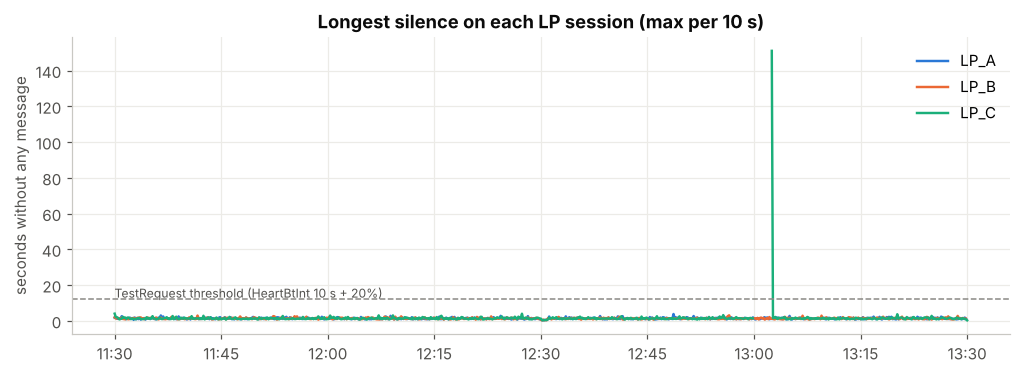

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.5))
for lp, g in inc.groupby("lp"):
    s = g.set_index("log_time").silence_s.resample("10s").max()
    ax.plot(s.index, s.values, color=P.LP_COLORS[lp], label=lp)
ax.axhline(12, color=P.NEUTRAL, ls="--", lw=1)
ax.text(inc.log_time.min(), 13, "TestRequest threshold (HeartBtInt 10 s + 20%)", color=P.INK_2, fontsize=8)
ax.set_title("Longest silence on each LP session (max per 10 s)")
ax.set_ylabel("seconds without any message"); P.time_axis(ax); ax.legend(); plt.show()

**LP_C went completely silent at 13:00:00**: no market data, no heartbeats. The bridge waited about 12 s, sent a
**TestRequest** (13:00:12), got no Heartbeat back and **logged out** after another 10 s (13:00:22).

**Why it matters:** for those **22 seconds** the bridge still held LP_C's *last* quotes as valid. Any order routed
to LP_C in that window went into a dead connection (see Lesson 05). A good bridge marks an LP's prices as
**stale/unusable after ~1–2 s without updates**, long before the session officially times out.

In [5]:
lpc_orders = msgs[(msgs.lp == "LP_C") & (msgs.msg_type == "D") &
                  (msgs.log_time.between("2025-10-15 12:59:59", "2025-10-15 13:00:22"))]
lpc_answers = msgs[(msgs.lp == "LP_C") & (msgs.msg_type == "8")].cl_ord_id
lpc_orders.assign(answered=lpc_orders.cl_ord_id.isin(lpc_answers))[["log_time", "cl_ord_id", "symbol", "side",
                                                                   "order_qty", "price", "answered"]]

,log_time,cl_ord_id,symbol,side,order_qty,price,answered
52766,2025-10-15 12:59:59.953,BR701128-1,XAUUSD,2,3.00,4096.8,False
52810,2025-10-15 13:00:07.278,BR701129-1,XAUUSD,2,0.29,4096.8,False
52860,2025-10-15 13:00:15.745,BR701131-1,XAUUSD,2,0.28,4096.8,False


Orders sent to LP_C just before and during the outage **never got an ExecutionReport**. The bridge timed them out
and rejected the clients, but **did LP_C execute them?** We can't know from our logs alone. Lesson 07 checks LP_C's
own trade statement and finds a fill the platform never booked.

## 3. Sequence numbers: detect gaps
Each side numbers its messages 1, 2, 3… (`34` MsgSeqNum). The receiver checks that each new number = previous + 1.
* **Higher than expected** → messages were lost, so send a ResendRequest.
* **Lower than expected** without `43=PossDupFlag=Y` → serious error, so disconnect.
* A **Logon with `141=Y`** restarts the numbering at 1.
* Messages with `43=Y` are **re-sent copies** and don't advance the sequence.

In [6]:
def sequence_gaps(df):
    out = []
    for (lp, d), g in df.sort_values(["log_time", "line"], kind="stable").groupby(["lp", "direction"]):
        expected = None
        for r in g.itertuples():
            if r.msg_type == "A" and r.reset_seq == "Y":
                expected = 1
            if r.poss_dup == "Y":
                continue
            if expected is not None and r.seq != expected:
                out.append(dict(lp=lp, direction=d, log_time=r.log_time, expected=expected, received=r.seq,
                                missing=r.seq - expected, msg=r.msg_name))
            expected = r.seq + 1
    return pd.DataFrame(out)

gaps = sequence_gaps(msgs)
gaps

,lp,direction,log_time,expected,received,missing,msg
0,LP_B,IN,2025-10-15 12:45:10.178,14129,14134,5,MarketDataSnapshotFullRefresh


In [7]:
g = gaps.iloc[0]
print(f"{g.lp} expected {g.expected:,} but received {g.received:,}: messages {g.expected:,}-{g.received - 1:,} "
      f"({g.missing} messages) were lost. Correct ResendRequest: 7={g.expected}, 16=0")

LP_B expected 14,129 but received 14,134: messages 14,129-14,133 (5 messages) were lost. Correct ResendRequest: 7=14129, 16=0


Only **one real gap** in the whole day, on LP_B. (Note: the log must be read in file order, because several
messages can share the same millisecond timestamp. Sorting by time alone would invent fake gaps.)

## 4. The recovery, and the bug in it
Correct behaviour: send `35=2` with **BeginSeqNo `7` = the first missing number** and `16=0`. Look at what the
bridge actually sent:

In [8]:
win = msgs[(msgs.lp == "LP_B") & msgs.log_time.between("2025-10-15 12:45:09.9", "2025-10-15 12:45:10.4")]
win[["log_time", "direction", "msg_name", "seq", "begin_seq", "end_seq", "new_seq", "gap_fill", "poss_dup",
     "orig_sending_time", "exec_id", "exec_type"]].fillna("")

,log_time,direction,msg_name,seq,begin_seq,end_seq,new_seq,gap_fill,poss_dup,orig_sending_time,exec_id,exec_type
44407,2025-10-15 12:45:10.178,IN,MarketDataSnapshotFullRefresh,14134,,,,,,,,
44408,2025-10-15 12:45:10.179,OUT,ResendRequest,508,14126,0,,,,,,
44409,2025-10-15 12:45:10.192,IN,SequenceReset,14126,,,14128,Y,Y,,,
44410,2025-10-15 12:45:10.192,IN,ExecutionReport,14128,,,,,Y,20251015-12:45:09.823,LP_B-E000075,F
44411,2025-10-15 12:45:10.193,IN,SequenceReset,14129,,,14134,Y,Y,,,
44416,2025-10-15 12:45:10.252,IN,MarketDataSnapshotFullRefresh,14135,,,,,,,,
44417,2025-10-15 12:45:10.274,IN,MarketDataSnapshotFullRefresh,14136,,,,,,,,
44418,2025-10-15 12:45:10.330,IN,MarketDataSnapshotFullRefresh,14137,,,,,,,,


**Reading the recovery:**
1. The bridge asked to resend from a number **three messages before** the first missing one (compare `begin_seq`
   with the gap above). That's a bug: it re-requests messages it had already processed.
2. LP_B answers correctly: market data is not worth re-sending, so it **gap-fills** (`35=4|123=Y`). Execution reports
   *must* be re-sent, so an ExecutionReport (a **fill**) comes back with **`43=Y`** (PossDup) and
   `122=OrigSendingTime`.
3. Then it gap-fills the 5 truly lost numbers, up to the message that revealed the gap.

**The danger:** message 8,596 had already been processed at 12:45:09. A correct bridge must check whether it has
already seen a PossDup message, using **ExecID (17)**, before acting on it. Did ours?

In [9]:
dup_exec = win[win.poss_dup == "Y"].exec_id.dropna().iloc[0]
msgs[msgs.exec_id == dup_exec][["lp", "log_time", "seq", "poss_dup", "exec_id", "cl_ord_id", "exec_type",
                                "last_qty", "last_px"]].fillna("")

,lp,log_time,seq,poss_dup,exec_id,cl_ord_id,exec_type,last_qty,last_px
44401,LP_B,2025-10-15 12:45:09.831,14128,,LP_B-E000075,BR700965-1,F,200000.0,1.16498
44410,LP_B,2025-10-15 12:45:10.192,14128,Y,LP_B-E000075,BR700965-1,F,200000.0,1.16498


Same ExecID and same sequence number, received twice: once original, once as a PossDup. In Lesson 07 we'll see that the platform **booked this
fill twice**, so the client got a duplicate deal and the broker's position no longer matches the LP's.

**Fix:** (1) send ResendRequest from the first missing sequence number; (2) de-duplicate execution reports on ExecID,
especially when `43=Y`.

## 5. Clocks: can we trust SendingTime?
One-way latency = time we **received** the message (our log time) − time the LP says it **sent** it (`52`).
That only works if both clocks are synchronised.

In [10]:
md = msgs[(msgs.msg_type == "W")].copy()
md["one_way_ms"] = (md.log_time - md.sending_time).dt.total_seconds() * 1000
stats = md.groupby("lp").one_way_ms.describe(percentiles=[.05, .5, .95]).round(1)
stats

,count,mean,std,min,5%,50%,95%,max
lp,,,,,,,,
LP_A,21854.0,3.3,0.9,2.0,2.0,3.0,5.0,11.0
LP_B,22149.0,8.8,0.9,8.0,8.0,9.0,10.0,16.0
LP_C,21733.0,-20.2,0.9,-21.0,-21.0,-20.0,-19.0,-13.0


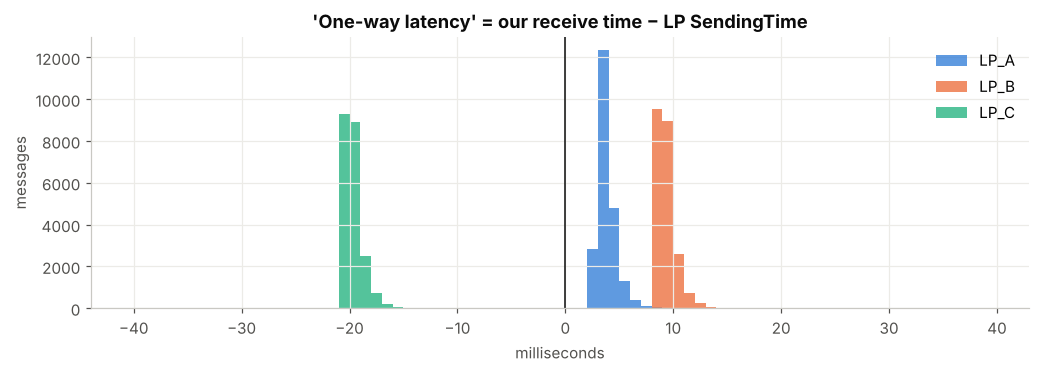

In [11]:
fig, ax = plt.subplots(figsize=(11, 3.2))
bins = np.arange(-40, 40, 1)
for lp, g in md.groupby("lp"):
    ax.hist(g.one_way_ms.clip(-40, 39), bins=bins, color=P.LP_COLORS[lp], alpha=0.75, label=lp)
ax.axvline(0, color=P.INK, lw=1)
ax.set_title("'One-way latency' = our receive time − LP SendingTime")
ax.set_xlabel("milliseconds"); ax.set_ylabel("messages"); ax.legend(); plt.show()

LP_C's market data seems to arrive **~20 ms before it was sent**, which is impossible. LP_C's clock is
**ahead** of ours.

**How to estimate the offset without trusting either clock:** use a round trip measured on *our* clock only.
The Logon exchange is ideal: we send a Logon and the LP answers immediately (no last-look hold).
* RTT = (our receive time of their Logon) − (our send time of our Logon), all on our clock
* One-way network delay ≈ RTT / 2 (assuming a symmetric path)
* Clock offset ≈ LP's SendingTime on its reply − (our send time + one-way delay)

In [12]:
lg = msgs[msgs.msg_type == "A"].sort_values(["log_time", "line"]).groupby(["lp", "direction"]).first()
rows = []
for lp in A.LPS:
    out, inn = lg.loc[(lp, "OUT")], lg.loc[(lp, "IN")]
    rtt = (inn.log_time - out.log_time).total_seconds() * 1000
    one_way = rtt / 2
    offset = ((inn.sending_time - out.log_time).total_seconds() * 1000) - one_way
    rows.append(dict(lp=lp, logon_rtt_ms=round(rtt, 1), one_way_ms=round(one_way, 1), est_clock_offset_ms=round(offset, 1),
                     median_md_apparent_latency_ms=round(md[md.lp == lp].one_way_ms.median(), 1)))
pd.DataFrame(rows).set_index("lp")

,logon_rtt_ms,one_way_ms,est_clock_offset_ms,median_md_apparent_latency_ms
lp,,,,
LP_A,7.0,3.5,0.5,3.0
LP_B,18.0,9.0,0.0,9.0
LP_C,10.0,5.0,25.0,-20.0


For LP_A and LP_B the estimated offset is ~0, so their SendingTimes can be trusted. **LP_C's clock is ~25 ms
ahead**, which explains the negative "latencies". Order round trips (D → 8) measured on our clock are unaffected:

In [13]:
d = msgs[msgs.msg_type == "D"][["lp", "cl_ord_id", "log_time"]].rename(columns={"log_time": "sent"})
r = (msgs[(msgs.msg_type == "8") & (msgs.poss_dup != "Y")].groupby(["lp", "cl_ord_id"]).log_time.min()
     .rename("first_answer").reset_index())
rt = d.merge(r, on=["lp", "cl_ord_id"])
rt["rtt_ms"] = (rt.first_answer - rt.sent).dt.total_seconds() * 1000
rt.groupby("lp").rtt_ms.describe(percentiles=[.5, .95]).round(1)

,count,mean,std,min,50%,95%,max
lp,,,,,,,
LP_A,390.0,41.3,113.9,5.0,7.0,410.1,472.0
LP_B,142.0,38.4,2.8,33.0,39.0,43.0,45.0
LP_C,328.0,132.7,16.8,105.0,133.0,158.0,162.0


The order round trip includes the LP's **last-look hold**: ~0 ms at LP_A, ~20 ms at LP_B, ~120 ms at LP_C.
Lesson 05 analyses that in detail.

**In practice:**
* Ask the LP for their time source (NTP vs PTP) and log both timestamps.
* Measure latency on **one clock only** (round trips) when clocks can't be trusted.
* Never mix clocks in TCA reports without correcting the offset.

## 6. Session health report
The daily check a bridge operations team runs for every LP session.

In [14]:
def health(df, lp):
    g = df[df.lp == lp]
    i = g[g.direction == "IN"].sort_values("log_time")
    return dict(
        lp=lp,
        messages_in=int((g.direction == "IN").sum()), messages_out=int((g.direction == "OUT").sum()),
        logons=int((g.msg_type == "A").sum() // 2), logouts=int((g.msg_type == "5").sum()),
        test_requests=int((g.msg_type == "1").sum()), resend_requests=int((g.msg_type == "2").sum()),
        seq_gaps=int((gaps.lp == lp).sum()) if len(gaps) else 0,
        possdup_received=int((i.poss_dup == "Y").sum()),
        max_silence_s=round(i.log_time.diff().dt.total_seconds().max(), 1),
        median_md_age_ms=round(i[i.msg_type == "W"].groupby("symbol").log_time.diff().dt.total_seconds().median() * 1000),
        clock_offset_flag="LP clock ahead" if md[md.lp == lp].one_way_ms.median() < 0 else "ok",
    )

pd.DataFrame([health(msgs, lp) for lp in A.LPS]).set_index("lp").T

lp,LP_A,LP_B,LP_C
messages_in,22288,22320,22118
messages_out,940,802,892
logons,1,1,2
logouts,0,0,1
test_requests,0,0,1
resend_requests,0,1,0
seq_gaps,0,1,0
possdup_received,0,3,0
max_silence_s,3.8,3.1,151.0
median_md_age_ms,675,670,655


## Takeaways
| Symptom | What to check | Typical root cause | Fix |
|---|---|---|---|
| Prices frozen for one LP | silence per session, TestRequests, Logouts | LP outage, network, LP-side throttling | Stale-quote filter (seconds, not heartbeat interval); alert on silence > 2 s |
| ResendRequest / GapFill in logs | sequence continuity, what was re-sent | packet loss, LP restart | ResendRequest from the first missing seq; never reset seq numbers to "fix" it |
| Same ExecID twice | PossDup handling | bridge ignores `43=Y` | De-duplicate on ExecID before booking |
| Negative one-way latency | SendingTime vs receive time | unsynchronised clocks | Round-trip measurement; NTP/PTP; correct offsets in TCA |
| Logon with `141=Y` mid-day | why the sequence was reset | manual "fix" after a disconnect | Avoid it: it throws away any message still in flight (Lesson 07) |

**Next:** Lesson 03, building the aggregated order book from market data.